In [21]:
import sys, os
from pathlib import Path

# Colab-specific setup
if 'google.colab' in sys.modules:
    if not os.path.exists("ioer-conference-2026-haclathon"):
        !git clone -q https://github.com/ioer-dresden/ioer-conference-2026-haclathon.git
    %cd -q ioer-conference-2026-haclathon/notebooks

# Install required packages
pyexec = sys.executable
!../py/modules/pkginstall.sh "{pyexec}" geopandas matplotlib requests

geopandas already installed (version 1.1.4).
matplotlib already installed (version 3.10.8).
requests already installed (version 2.32.5).


In [22]:
#import cell
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import requests

# 🌿 Urban Green for Climate Regulation

* **Authors**: Marzan Tasnim Oyshi (IOER) 
* **Topics**: Urban Green Infrastructure, Climate Regulation, Ecosystem Services, Open Data Re-use, Reproducible Research
*  **Badges**: ![Interactive](https://img.shields.io/badge/Type-Interactive_Code-blue?style=flat-square) ![Colab](https://img.shields.io/badge/Colab-Tested-yellow?style=flat-square&logo=googlecolab&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter4NFDI-Ready-orange?style=flat-square&logo=jupyter)

```{admonition} Summary
:class: hint
How much can urban green infrastructure contribute to climate regulation in German cities and how many people benefit from it?

In this chapter, we reuse the openly published ioerDATA replication package **Climate Regulation in Cities** to explore a national ecosystem-service indicator for urban climate regulation.

We will:

- access an openly published replication package,
- explore spatial indicators for German cities,
- investigate cooling capacity provided by urban green infrastructure,
- compare cooling capacity with population benefit,
- create reproducible maps and visualisations,
- and explore how the data could support urban planning.

The aim is to demonstrate how published research data can be **reused, explored, and extended**.
```

```{warning}
This chapter is a work in progress.
```

---

## 1. Why does urban green matter?

Cities are particularly vulnerable to heat.

Buildings, sealed surfaces, roads, and other artificial surfaces can store heat and contribute to the **urban heat island effect**. Green infrastructure can counteract some of these effects through shading, evapotranspiration, and other local climate-regulation processes.

Urban green infrastructure includes elements such as:

- trees,
- parks,
- urban forests,
- gardens,
- grass and vegetated surfaces,
- and other green spaces.

But simply asking **"How green is a city?"** is not enough.

For climate adaptation, we are also interested in:

> **Where does urban green provide cooling capacity, and how many people may benefit from it?**

This notebook explores that question using an openly available research dataset.

## 2. From publication to reusable research data

The analysis is based on the ioerDATA replication package:

> **Replication package for: Climate Regulation in Cities**

The dataset provides a national indicator of local climate regulation by urban green infrastructure for **165 German cities with more than 50,000 inhabitants**.

It contains information on:

- urban green infrastructure,
- cooling capacity,
- population,
- and the proportion of inhabitants benefiting from climate-regulating ecosystem services.

The replication package accompanies the publication:

*Assessment and Monitoring of Local Climate Regulation in Cities by Green Infrastructure — A National Ecosystem Service Indicator for Germany.*

This gives us an opportunity to move beyond simply reading a scientific publication.

Instead, we can directly inspect and reuse the underlying research data.

## ♻️ Reproducibility first

A scientific figure is much more useful when we can understand:

1. **where the data came from,**
2. **how it was processed,**
3. **which indicators were created,**
4. **and how the final visualisation was produced.**

This notebook therefore keeps the complete workflow visible and executable.

The same data can then be reused for questions that were not necessarily part of the original publication.

## 3. Access the replication package

The dataset is published through **ioerDATA**, which is based on Dataverse.

Instead of manually downloading the GeoPackage, we can retrieve it programmatically.

This is useful because the source of the data becomes part of the analysis itself.

In [23]:
dataset_doi = "doi:10.71830/AFW3N3"

api_url = (
    "https://data.fdz.ioer.de/api/datasets/:persistentId/"
    f"?persistentId={dataset_doi}"
)

metadata = requests.get(api_url).json()
files = metadata["data"]["latestVersion"]["files"]

for item in files:
    print(item["dataFile"]["filename"])

Assessment_and_Monitoring_of_Local_Climate_Regulation.pdf
Climate_regulation_in_cities_as_an_ecosystem_service_German.pdf
Cooling_Capacity_2018_buffered.gdb.zip
Documentation.md
Figure_1_Urban_green_Infrastructure_Syrbe_KLu-04.png
Map_1_Climate_regulation_Air_Photo.jpg
Map_2_Climate_regulation_Tree_Cover.jpg
Map_3_Climate_regulation_Population.jpg
Map_4_Climate_regulation_Cooling_Capacity.jpg
Map_5_Cities_cooling_capacity.jpg
Map_6_Cities_inhabitants_cooling_capacity.jpg
README.md
Stadtklima_Skript.py
climate_regulation_in_cities.gpkg


## 3. Download the replication package

The replication package is published on **ioerDATA** and can be accessed through the Dataverse API.

Some files are public, while others are **restricted** and require authentication. A personal API token allows the notebook to authenticate with ioerDATA and download all files your account is permitted to access.

> ⚠️ **Keep your API token private.** Never save it in the notebook or commit it to GitHub.

In [24]:
from pathlib import Path
from getpass import getpass
import requests

base_url = "https://data.fdz.ioer.de"
persistent_id = "doi:10.71830/AFW3N3"

# Authenticate securely
api_token = getpass("Paste your ioerDATA API token: ")
headers = {"X-Dataverse-key": api_token}

# Get dataset metadata and file list
url = f"{base_url}/api/datasets/:persistentId/"
metadata = requests.get(
    url,
    params={"persistentId": persistent_id},
    headers=headers
).json()

files = metadata["data"]["latestVersion"]["files"]

# Prepare download folder
data_dir = Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

print(f"{len(files)} files found.")

Paste your ioerDATA API token:  ········


14 files found.


In [25]:
for item in files:
    file = item["dataFile"]
    filename = file["filename"]
    output = data_dir / filename

    response = requests.get(
        f"{base_url}/api/access/datafile/{file['id']}",
        headers=headers,
        stream=True
    )

    if response.status_code in (401, 403):
        print(f"Skipped: {filename} — no permission")
        continue

    response.raise_for_status()

    with open(output, "wb") as f:
        for chunk in response.iter_content(1024 * 1024):
            if chunk:
                f.write(chunk)

    access = "restricted" if item.get("restricted") else "public"
    print(f"Downloaded: {filename} ({access})")

Downloaded: Assessment_and_Monitoring_of_Local_Climate_Regulation.pdf (public)
Downloaded: Climate_regulation_in_cities_as_an_ecosystem_service_German.pdf (public)
Downloaded: Cooling_Capacity_2018_buffered.gdb.zip (public)
Downloaded: Documentation.md (public)
Downloaded: Figure_1_Urban_green_Infrastructure_Syrbe_KLu-04.png (public)
Downloaded: Map_1_Climate_regulation_Air_Photo.jpg (public)
Downloaded: Map_2_Climate_regulation_Tree_Cover.jpg (public)
Downloaded: Map_3_Climate_regulation_Population.jpg (public)
Downloaded: Map_4_Climate_regulation_Cooling_Capacity.jpg (public)
Downloaded: Map_5_Cities_cooling_capacity.jpg (public)
Downloaded: Map_6_Cities_inhabitants_cooling_capacity.jpg (public)
Downloaded: README.md (public)
Downloaded: Stadtklima_Skript.py (public)
Downloaded: climate_regulation_in_cities.gpkg (restricted)


## 4. Load the spatial data

The main spatial dataset is stored as a GeoPackage. We load it with GeoPandas and inspect the available indicators before mapping them.

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt

gpkg_path = data_dir / "climate_regulation_in_cities.gpkg"

gdf = gpd.read_file(gpkg_path)

print(f"Features: {len(gdf)}")
print(f"CRS: {gdf.crs}")

gdf.head()

Features: 165
CRS: EPSG:3035


,AGS,GEN,NUTS,Shape_Leng,Shape_Area,Pop_Benefit_Percent,geometry
0,09563000,Fürth,DE253,49209.551437,6.334375e+07,49.550707,"MULTIPOLYGON (((4392577.758 2936451.016, 43926..."
1,09162000,München,DE212,118084.194383,3.108342e+08,70.270877,"MULTIPOLYGON (((4432133.707 2774479.63, 443212..."
2,09461000,Bamberg,DE241,44492.667416,5.464215e+07,77.048748,"MULTIPOLYGON (((4388203.406 2978639.586, 43882..."
3,09262000,Passau,DE222,61360.769487,6.956591e+07,78.069768,"MULTIPOLYGON (((4570163.06 2838978.815, 457018..."
4,09564000,Nürnberg,DE254,153997.952475,1.866370e+08,46.746620,"MULTIPOLYGON (((4401927.814 2917518.273, 44019..."


This is the checkpoint where you identify the exact columns for:

>city name, cooling capacity, population benefit

In [27]:
gdf.columns.tolist()

['AGS',
 'GEN',
 'NUTS',
 'Shape_Leng',
 'Shape_Area',
 'Pop_Benefit_Percent',
 'geometry']

## 5. Where is climate-regulation capacity high?

Urban green infrastructure provides different levels of cooling capacity across German cities.

Mapping the indicator helps reveal where climate-regulation potential is comparatively high or low.

In [28]:
#prepare map context
import matplotlib.patheffects as pe

value_col = "Pop_Benefit_Percent"
name_col = "GEN"
gdf_wgs = gdf.to_crs("EPSG:4326")

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
germany = world[world["NAME"] == "Germany"]

major_cities = {
    "Berlin", "Hamburg", "München", "Dresden",
    "Köln", "Leipzig", "Frankfurt am Main", "Bremen"
}
labels = gdf_wgs[gdf_wgs[name_col].isin(major_cities)]

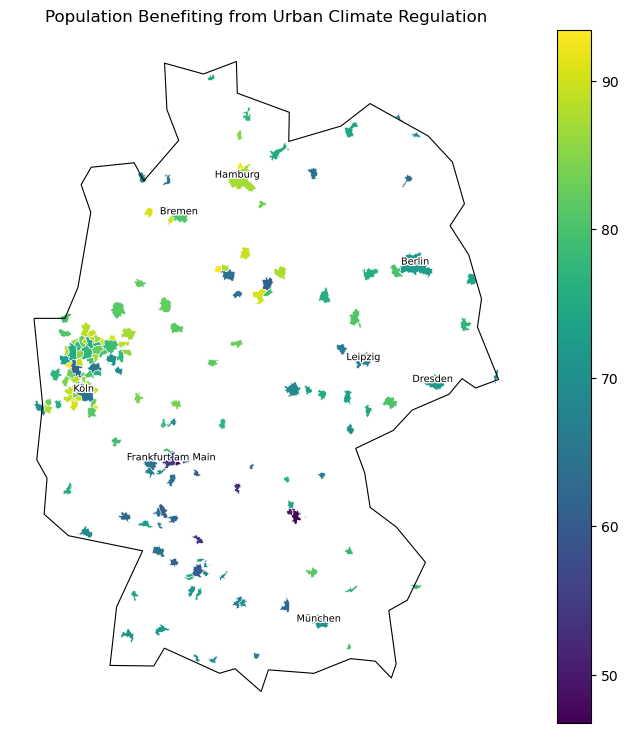

In [29]:
#map the indicator
fig, ax = plt.subplots(figsize=(9, 9))

gdf_wgs.plot(
    column=value_col,
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

germany.boundary.plot(ax=ax, color="black", linewidth=0.8)

for _, row in labels.iterrows():
    p = row.geometry.representative_point()
    txt = ax.text(p.x, p.y, row[name_col], fontsize=7, ha="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

ax.set_title("Population Benefiting from Urban Climate Regulation")
ax.set_axis_off()

plt.show()

### What does the map show?

The indicator represents the **share of inhabitants benefiting from the cooling effect of urban green infrastructure**.

The map reveals that this benefit varies between German cities. This shifts the focus from simply asking *where green infrastructure exists* to asking:

> **How effectively does urban green infrastructure provide climate-regulation benefits to people?**

## 6. From replication to exploration

Reproducing the indicator map is only the starting point.

Because the replication package provides reusable spatial data, we can explore additional questions:

- Which cities show particularly high or low population benefit?
- How do cities compare with each other?
- What might these differences mean for urban green planning?

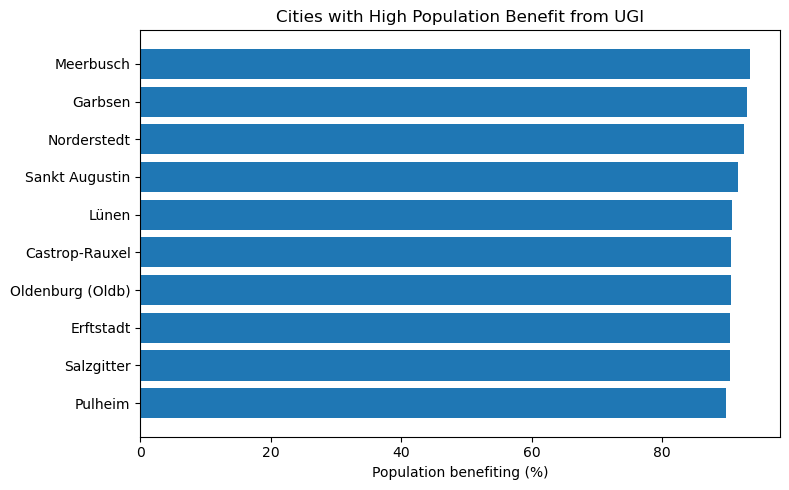

In [30]:
#compare cities
top = gdf.nlargest(10, value_col).sort_values(value_col)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(top[name_col], top[value_col])
ax.set_xlabel("Population benefiting (%)")
ax.set_title("Cities with High Population Benefit from UGI")

plt.tight_layout()
plt.show()

## Try it yourself

Open data makes it possible to move beyond reproduction.

Try changing the analysis:

- Find the cities with the **lowest** population benefit.
- Select a city you know and compare it with others.
- Explore another file from the replication package.

> **Replication reproduces evidence. Reuse creates opportunities for new questions.**

## Conclusion

This example moves from:

**open research data → spatial indicator → city comparison → planning question**

Urban green infrastructure is not only about the amount of green space. Its relevance also depends on the **climate-regulation service it provides and the population that benefits from it**.

The ioerDATA replication package makes this evidence accessible for reproduction, exploration, and further research.